In [ ]:
import zipfile
from google.colab import files
import os
zip_file_path = '/content/facial expression classification.zip'
extracted_dir = '/content/facial_expression'
os.makedirs(extracted_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)

print(f"Extracted files to: {extracted_dir}")

dataset_path = os.path.join(extracted_dir, 'facial expression classification')

Extracted files to: /content/facial_expression


In [ ]:
import os
import glob
import shutil
from collections import defaultdict, Counter
from tqdm import tqdm
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input, Add, Activation
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
from tensorflow.keras.regularizers import l2
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
import math
import time
import itertools

In [ ]:
dataset_path = '/content/facial_expression/facial expression classification'

# Define the splits and classes
splits = ['train', 'test', 'validation']
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [ ]:
# Count the number of images per class for each split
image_counts = defaultdict(lambda: defaultdict(int))

for split in splits:
    split_path = os.path.join(dataset_path, split)
    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        # Count the number of images in each class folder
        if os.path.exists(cls_path):
            image_counts[split][cls] = len(glob.glob(os.path.join(cls_path, '*.*')))

<ipython-input-6-f2de59ea6fca>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=classes, palette='viridis')
<ipython-input-6-f2de59ea6fca>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=classes, palette='viridis')
<ipython-input-6-f2de59ea6fca>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=classes, palette='viridis')


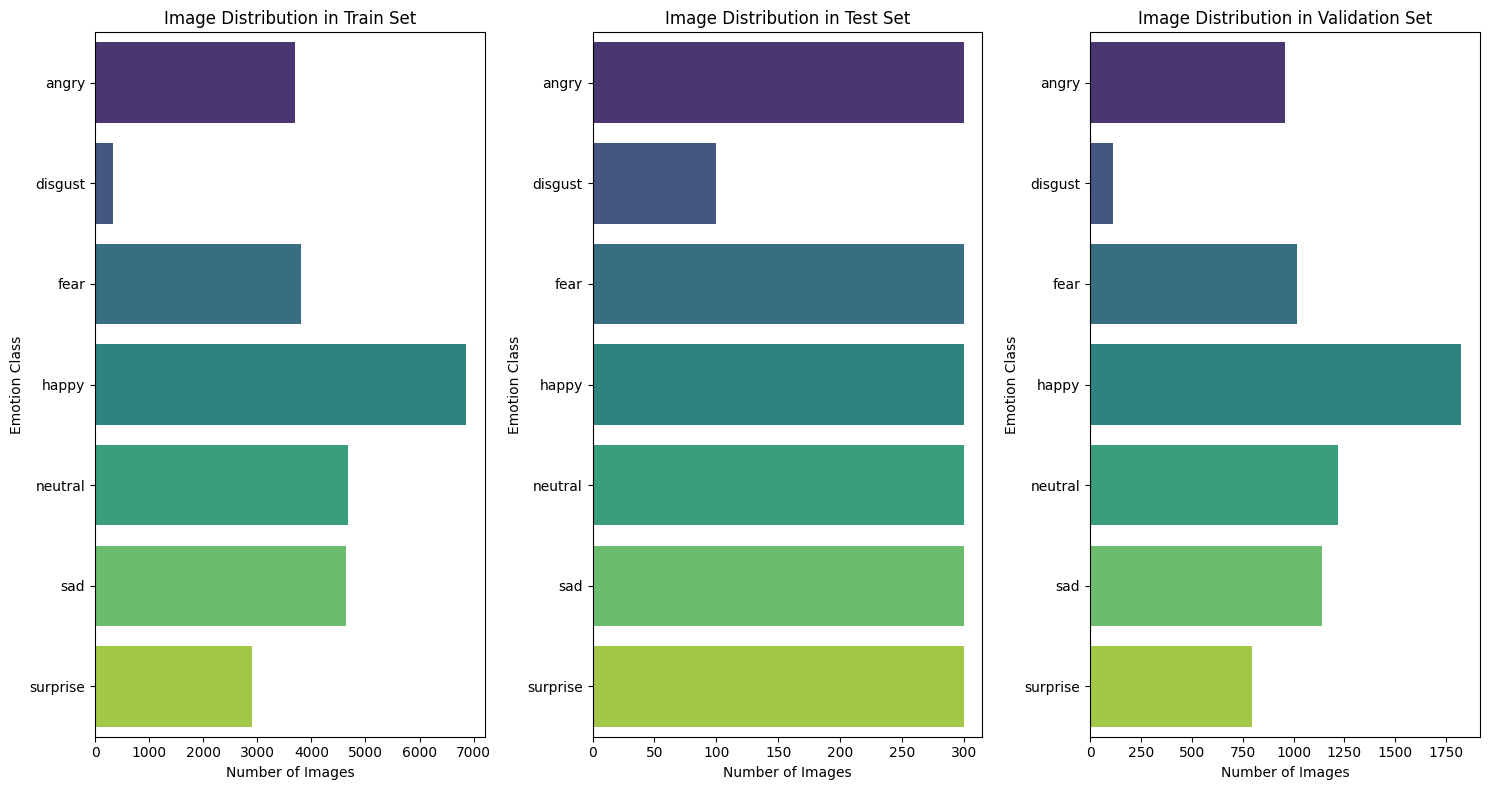

In [ ]:
# Visualize the distribution of images per class for each split
plt.figure(figsize=(15, 8))

for i, split in enumerate(splits, 1):
    plt.subplot(1, 3, i)
    counts = [image_counts[split][cls] for cls in classes]
    sns.barplot(x=counts, y=classes, palette='viridis')
    plt.title(f'Image Distribution in {split.capitalize()} Set')
    plt.xlabel('Number of Images')
    plt.ylabel('Emotion Class')

plt.tight_layout()
plt.show()


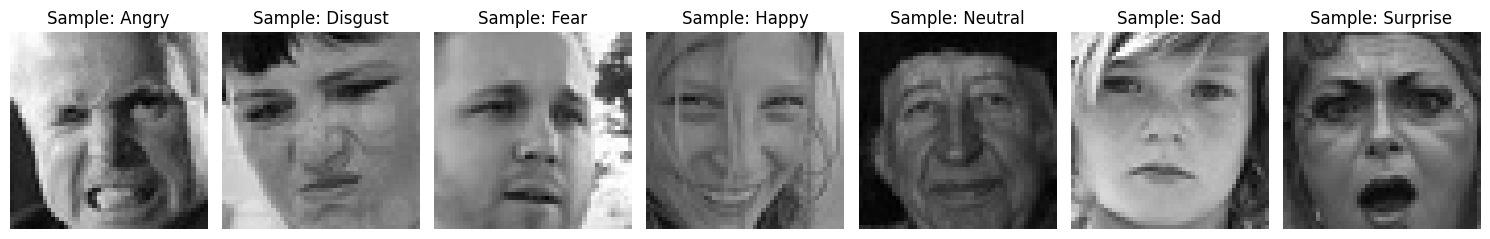

In [ ]:
 # Display sample images from a few classes
plt.figure(figsize=(15, 5))
for i, cls in enumerate(classes):
    cls_path = os.path.join(dataset_path, 'train', cls)
    image_files = glob.glob(os.path.join(cls_path, '*.*'))
    if len(image_files) > 0:
        img_path = image_files[0]
        img = Image.open(img_path).convert('RGB')
        img_array = np.array(img)
        plt.subplot(1, len(classes), i+1)
        plt.imshow(img_array)
        plt.title(f'Sample: {cls.capitalize()}')
        plt.axis('off')
    else:
        print(f"No images found for {cls}")

plt.tight_layout()
plt.show()

In [ ]:
# Print key statistics
total_images = 0
for split in splits:
    split_total = sum(image_counts[split].values())
    total_images += split_total
    print(f"\nTotal images in {split} set: {split_total}")
    for cls in classes:
        print(f" - {cls}: {image_counts[split][cls]} images")
print(f"\nTotal images across all sets: {total_images}")


Total images in train set: 26921
 - angry: 3693 images
 - disgust: 336 images
 - fear: 3803 images
 - happy: 6864 images
 - neutral: 4682 images
 - sad: 4638 images
 - surprise: 2905 images

Total images in test set: 1900
 - angry: 300 images
 - disgust: 100 images
 - fear: 300 images
 - happy: 300 images
 - neutral: 300 images
 - sad: 300 images
 - surprise: 300 images

Total images in validation set: 7066
 - angry: 960 images
 - disgust: 111 images
 - fear: 1018 images
 - happy: 1825 images
 - neutral: 1216 images
 - sad: 1139 images
 - surprise: 797 images

Total images across all sets: 35887


In [ ]:
# Analyze class distribution in training set
emotions = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
train_dir = os.path.join(dataset_path, 'train')
class_counts = {}

for emotion in emotions:
    emotion_path = os.path.join(train_dir, emotion)
    if os.path.exists(emotion_path):
        class_counts[emotion] = len(os.listdir(emotion_path))

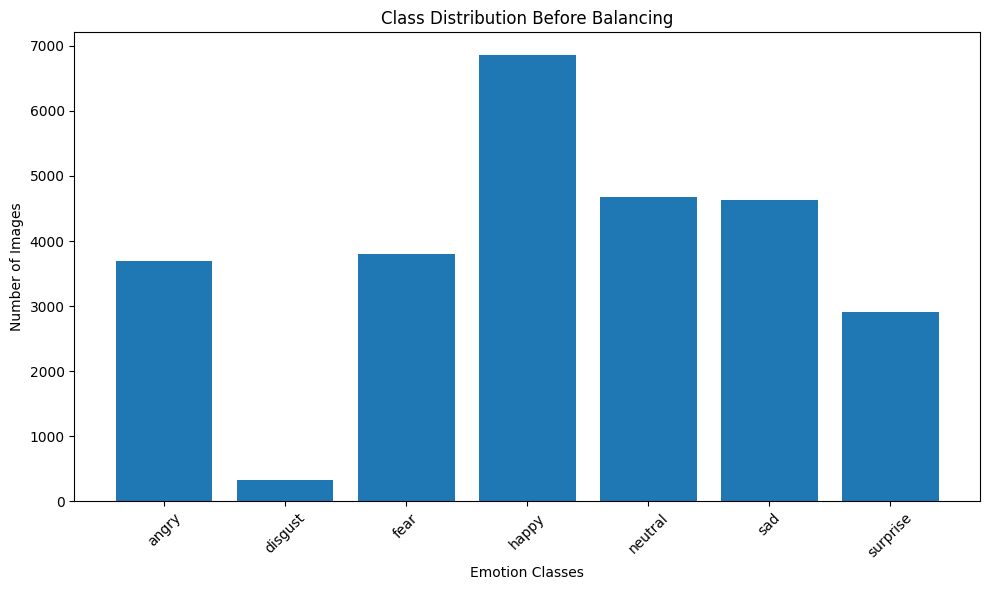

Class distribution before balancing:
angry: 3693 images
disgust: 336 images
fear: 3803 images
happy: 6864 images
neutral: 4682 images
sad: 4638 images
surprise: 2905 images


In [ ]:
# Display class distribution
plt.figure(figsize=(10, 6))
plt.bar(class_counts.keys(), class_counts.values())
plt.title('Class Distribution Before Balancing')
plt.xlabel('Emotion Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Class distribution before balancing:")
for cls, count in class_counts.items():
    print(f"{cls}: {count} images")

In [ ]:
# Create a balanced dataset directory
balanced_dir = os.path.join(dataset_path, 'balanced_train')
os.makedirs(balanced_dir, exist_ok=True)

# Find the median class size for reference
median_size = np.median(list(class_counts.values()))
# Find the maximum class size
max_size = max(class_counts.values())
# Find the minimum class size
min_size = min(class_counts.values())

# Target size for each class after balancing
target_size = int(median_size * 1.2)  # Slightly above median
print(f"Target size for each class: {target_size}")

Target size for each class: 4563


In [ ]:
# Create augmentation generator for upsampling with augmentation
augmentation_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [ ]:
# Process each class
for emotion in emotions:
    class_path = os.path.join(train_dir, emotion)
    if not os.path.exists(class_path):
        continue

    # Create directory for this class in the balanced dataset
    balanced_class_dir = os.path.join(balanced_dir, emotion)
    os.makedirs(balanced_class_dir, exist_ok=True)

    # Get all images in this class
    images = os.listdir(class_path)
    current_count = len(images)

    # Determine if we need to upsample or downsample
    if current_count >= target_size * 1.5:
        # Downsample for classes with many more images than target
        print(f"Downsampling {emotion} from {current_count} to {target_size}")
        selected_images = np.random.choice(images, target_size, replace=False)

        # Copy selected images to balanced directory
        for img_name in tqdm(selected_images, desc=f"Downsampling {emotion}"):
            src = os.path.join(class_path, img_name)
            dst = os.path.join(balanced_class_dir, img_name)
            shutil.copy(src, dst)

    elif current_count < target_size:
        # Upsample with augmentation for classes with fewer images
        print(f"Upsampling {emotion} from {current_count} to {target_size}")

        # First, copy all original images
        for img_name in images:
            src = os.path.join(class_path, img_name)
            dst = os.path.join(balanced_class_dir, img_name)
            shutil.copy(src, dst)

        # Apply extra augmentation for disgust class
        extra_augmentation = emotion.lower() == 'disgust'

        # Then generate augmented images to reach target size
        images_to_generate = target_size - current_count
        source_images = [os.path.join(class_path, img) for img in images]

        # Use more augmentation iterations for classes with very few samples
        augmentation_factor = 5 if extra_augmentation else 3

        for i in tqdm(range(images_to_generate), desc=f"Augmenting {emotion}"):
            # Select a random image to augment
            img_path = np.random.choice(source_images)
            img = cv2.imread(img_path)
            if img is None:
                continue

            # Convert to RGB if needed
            if len(img.shape) == 2:  # If grayscale
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            elif img.shape[2] == 1:  # If grayscale with channel dimension
                img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
            else:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            img = img.reshape((1,) + img.shape)

            # Generate a batch of augmented images
            augmentation_batch = next(augmentation_datagen.flow(
                img,
                batch_size=1,
                save_to_dir=balanced_class_dir,
                save_prefix=f"{emotion}_aug_{i}",
                save_format='jpg'
            ))
    else:
        # For classes close to target size, just copy all images
        print(f"Keeping {emotion} with {current_count} images (close to target)")
        for img_name in tqdm(images, desc=f"Copying {emotion}"):
            src = os.path.join(class_path, img_name)
            dst = os.path.join(balanced_class_dir, img_name)
            shutil.copy(src, dst)


Upsampling angry from 3693 to 4563


Augmenting angry: 100%|██████████| 870/870 [00:01<00:00, 494.46it/s]


Upsampling disgust from 336 to 4563


Augmenting disgust: 100%|██████████| 4227/4227 [00:05<00:00, 769.77it/s]


Upsampling fear from 3803 to 4563


...

Copying neutral: 100%|██████████| 4682/4682 [00:00<00:00, 11329.95it/s]


Keeping sad with 4638 images (close to target)


Copying sad: 100%|██████████| 4638/4638 [00:00<00:00, 12662.58it/s]


Upsampling surprise from 2905 to 4563


Augmenting surprise: 100%|██████████| 1658/1658 [00:03<00:00, 549.67it/s]


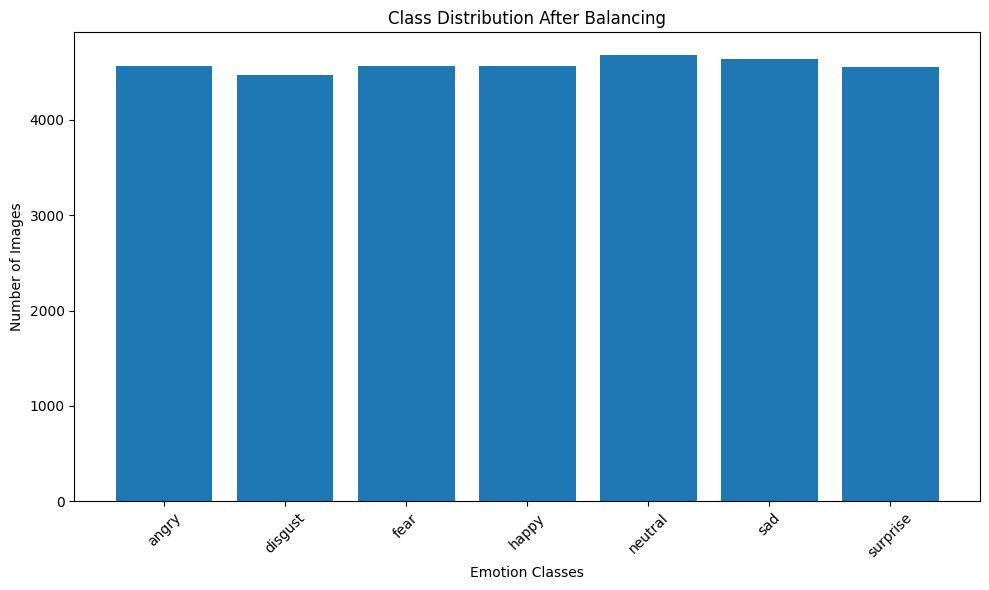


Class distribution after balancing:
angry: 4561 images
disgust: 4471 images
fear: 4561 images
happy: 4563 images
neutral: 4682 images
sad: 4638 images
surprise: 4558 images

Balanced dataset created successfully!


In [ ]:
# Verify the balanced dataset
balanced_class_counts = {}
for emotion in emotions:
    balanced_class_path = os.path.join(balanced_dir, emotion)
    if os.path.exists(balanced_class_path):
        balanced_class_counts[emotion] = len(os.listdir(balanced_class_path))

# Display balanced class distribution
plt.figure(figsize=(10, 6))
plt.bar(balanced_class_counts.keys(), balanced_class_counts.values())
plt.title('Class Distribution After Balancing')
plt.xlabel('Emotion Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
print("\nClass distribution after balancing:")
for cls, count in balanced_class_counts.items():
    print(f"{cls}: {count} images")

print("\nBalanced dataset created successfully!")


In [ ]:
image_size = (48, 48)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.15,
    fill_mode='nearest'
)

In [ ]:
# Update the training data generator to use the balanced dataset
balanced_train_generator = train_datagen.flow_from_directory(
    balanced_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=True
)

print(f"\nUpdated training generator with balanced dataset: {balanced_train_generator.samples} samples")
print(f"Class distribution in balanced training generator: {balanced_train_generator.class_indices}")

Found 32034 images belonging to 7 classes.

Updated training generator with balanced dataset: 32034 samples
Class distribution in balanced training generator: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [ ]:
print("CHECKING FOR CORRUPTED IMAGES AFTER AUGMENTATION")
print("-" * 50)

# Create backup directory for corrupted images
post_aug_backup_dir = '/content/post_augmentation_corrupted_images'
os.makedirs(post_aug_backup_dir, exist_ok=True)
print(f"Created backup directory: {post_aug_backup_dir}")

# Statistics tracking
post_aug_corrupted_stats = {
    'total_images': 0,
    'corrupted_images': 0,
    'by_emotion': {emotion: 0 for emotion in emotions},
}

def check_image_validity(image_path):
    try:
        # Check if file exists and has size
        if not os.path.exists(image_path) or os.path.getsize(image_path) == 0:
            return False

        # Try to open and verify the image
        with Image.open(image_path) as img:
            # Force loading the image data to check if it's corrupted
            img.load()

            # Verify image mode and dimensions
            if img.mode not in ['L', 'RGB', 'P']:
                return False

            # Check image size
            width, height = img.size
            if width == 0 or height == 0:
                return False

            # Try to convert to array to ensure it's fully readable
            img_array = np.array(img)
            if img_array.size == 0:
                return False

            # Try to resize to target size (as the generator would)
            resized = img.resize((48, 48))
            _ = np.array(resized)

            return True
    except Exception as e:
        print(f"Error validating image {image_path}: {e}")
        return False

CHECKING FOR CORRUPTED IMAGES AFTER AUGMENTATION
--------------------------------------------------
Created backup directory: /content/post_augmentation_corrupted_images


In [ ]:
# Scan and remove corrupted images from balanced dataset
balanced_dir = os.path.join(dataset_path, 'balanced_train')
print("\nScanning balanced dataset for corruption...")

for emotion in emotions:
    emotion_path = os.path.join(balanced_dir, emotion)

    if not os.path.exists(emotion_path):
        print(f"  - {emotion}: Directory not found")
        continue

    # Get all image files
    image_files = glob.glob(os.path.join(emotion_path, '*.*'))
    corrupted_count = 0

    print(f"  - {emotion}: ", end='')

    # Check each image
    valid_images = []
    for img_path in tqdm(image_files, desc=f"Checking {emotion}", leave=False):
        post_aug_corrupted_stats['total_images'] += 1
        if check_image_validity(img_path):
            valid_images.append(img_path)
        else:
            # Move corrupted image to backup
            relative_path = os.path.relpath(img_path, balanced_dir)
            backup_path = os.path.join(post_aug_backup_dir, relative_path)
            os.makedirs(os.path.dirname(backup_path), exist_ok=True)

            try:
                shutil.move(img_path, backup_path)
            except Exception as e:
                print(f"Error moving {img_path}: {e}")
                # If move fails, try to delete
                try:
                    os.remove(img_path)
                except:
                    pass

            corrupted_count += 1
            post_aug_corrupted_stats['corrupted_images'] += 1
            post_aug_corrupted_stats['by_emotion'][emotion] += 1



In [ ]:
# Print corruption summary
print("\nPOST-AUGMENTATION CORRUPTION CHECK SUMMARY:")
print(f"Total images scanned: {post_aug_corrupted_stats['total_images']}")
print(f"Total corrupted images removed: {post_aug_corrupted_stats['corrupted_images']}")

if post_aug_corrupted_stats['corrupted_images'] > 0:
    print("\nBy emotion:")
    for emotion in emotions:
        if post_aug_corrupted_stats['by_emotion'][emotion] > 0:
            print(f"  - {emotion}: {post_aug_corrupted_stats['by_emotion'][emotion]} corrupted")

print(f"\nCorrupted images backed up to: {post_aug_backup_dir}")


POST-AUGMENTATION CORRUPTION CHECK SUMMARY:
Total images scanned: 32034
Total corrupted images removed: 46

By emotion:
  - angry: 7 corrupted
  - disgust: 7 corrupted
  - fear: 7 corrupted
  - happy: 4 corrupted
  - neutral: 7 corrupted
  - sad: 7 corrupted
  - surprise: 7 corrupted

Corrupted images backed up to: /content/post_augmentation_corrupted_images


In [ ]:
# Verify final class distribution after corruption removal
final_class_counts = {}
for emotion in emotions:
    emotion_path = os.path.join(balanced_dir, emotion)
    if os.path.exists(emotion_path):
        final_class_counts[emotion] = len(os.listdir(emotion_path))



Final class distribution after corruption removal:
angry: 4554 images
disgust: 4464 images
fear: 4554 images
happy: 4559 images
neutral: 4675 images
sad: 4631 images
surprise: 4551 images


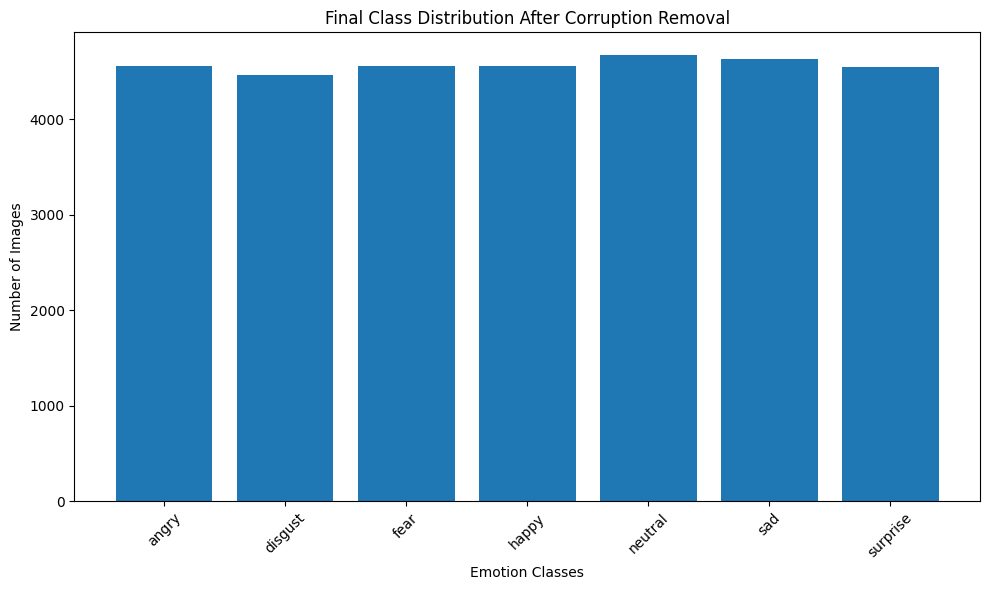

In [ ]:
# Display final class distribution
plt.figure(figsize=(10, 6))
plt.bar(final_class_counts.keys(), final_class_counts.values())
plt.title('Final Class Distribution After Corruption Removal')
plt.xlabel('Emotion Classes')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('final_class_distribution.png')

print("\nFinal class distribution after corruption removal:")
for cls, count in final_class_counts.items():
    print(f"{cls}: {count} images")

In [ ]:
# Update the balanced training generator after corruption removal
balanced_train_generator = train_datagen.flow_from_directory(
    balanced_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=True
)

print(f"\nUpdated balanced training generator: {balanced_train_generator.samples} samples")
print("-" * 50)

Found 31988 images belonging to 7 classes.

Updated balanced training generator: 31988 samples
--------------------------------------------------


In [ ]:
# Check for corrupted images in the training dataset
print("\nCHECK FOR CORRUPTED IMAGES IN TRAINING DATASET:")
train_backup_dir = '/content/train_corrupted_images'
os.makedirs(train_backup_dir, exist_ok=True)
print(f"Created backup directory for training dataset: {train_backup_dir}")



CHECK FOR CORRUPTED IMAGES IN TRAINING DATASET:
Created backup directory for training dataset: /content/train_corrupted_images


In [ ]:
# Statistics tracking for training dataset
train_corrupted_stats = {
    'total_images': 0,
    'corrupted_images': 0,
    'by_emotion': {emotion: 0 for emotion in emotions},
}

In [ ]:
# Create a more robust data generator for training
class SafeImageDataGenerator(ImageDataGenerator):
    def flow_from_directory(self, *args, **kwargs):
        generator = super().flow_from_directory(*args, **kwargs)

        # Store the original next method
        original_next = generator.__next__

        # Define a safer next method
        def safe_next():
            try:
                return original_next()
            except Exception as e:
                print(f"Warning: Skipping problematic batch: {e}")
                # Try again with the next batch
                return safe_next()

        # Replace the next method
        generator.__next__ = safe_next
        return generator

In [ ]:
# Define model parameters
num_classes = len(emotions)  # 7 emotions
input_shape = (48, 48, 1)    # 48x48 grayscale images

In [ ]:
# Define image parameters
image_size = (48, 48)
batch_size = 32

In [ ]:
# Create validation and test generators
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [ ]:
# Load validation and test data
validation_generator = val_datagen.flow_from_directory(
    os.path.join(dataset_path, 'validation'),
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    os.path.join(dataset_path, 'test'),
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=False
)


Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.


In [ ]:
# Ensure the augmented and balanced data are being used
if 'balanced_train_generator' not in locals():
    # Create a balanced generator using the same augmentation as before
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        horizontal_flip=True,
        zoom_range=0.15,
        fill_mode='nearest'
    )

    balanced_train_generator = train_datagen.flow_from_directory(
        os.path.join(dataset_path, 'train'),
        target_size=image_size,
        batch_size=batch_size,
        class_mode='categorical',
        color_mode='grayscale',
        shuffle=True
    )

In [ ]:
# Create a baseline CNN model
def baseline_model():
    model = Sequential([
        # First Convolutional Layer
        Conv2D(64, kernel_size=(5, 5), activation='relu', padding='same', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),

        # Second Convolutional Layer
        Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),

        # Third Convolutional Layer
        Conv2D(256, kernel_size=(3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),

        # Flatten the output for fully connected layers
        Flatten(),

        # First Fully Connected Layer
        Dense(512, activation='relu'),

        # Second Fully Connected Layer
        Dense(256, activation='relu'),

        # Third Fully Connected Layer
        Dense(128, activation='relu'),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    # Correct the indentation here
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Create the improved model
baseline = baseline_model()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Print model summary
print("MODEL SUMMARY:")
baseline.summary()

MODEL SUMMARY:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,254,919 (20.05 MB)

 Trainable params: 5,254,919 (20.05 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the model
print("\n MODEL:")
epochs = 25

steps_per_epoch = math.ceil(balanced_train_generator.samples / batch_size)
validation_steps = math.ceil(validation_generator.samples / batch_size)

# Use the balanced training generator
history = baseline.fit(
    balanced_train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    verbose=1
)


 MODEL:
Epoch 1/25


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 35s 30ms/step - accuracy: 0.1706 - loss: 1.9272 - val_accuracy: 0.2567 - val_loss: 1.7967
Epoch 2/25
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 26s 25ms/step - accuracy: 0.2638 - loss: 1.8278 - val_accuracy: 0.3491 - val_loss: 1.6455
Epoch 3/25
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.3147 - loss: 1.7441 - val_accuracy: 0.3960 - val_loss: 1.5740
Epoch 4/25
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.3492 - loss: 1.6704 - val_accuracy: 0.4082 - val_loss: 1.5118
Epoch 5/25
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.3889 - loss: 1.5900 - val_accuracy: 0.4738 - val_loss: 1.3917
Epoch 6/25
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.4192 - loss: 1.5140 - val_accuracy: 0.4888 - val_loss: 1.3402
Epoch 7/25
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.4399 - loss: 1.4691 - val_accuracy: 0.5037 - val_loss: 1.3025
Epoch 8/25
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 25s 25ms/step - accuracy: 0.4573 - loss: 1.40

In [ ]:
# Save the model
baseline.save('baseline_model.h5')
print("Model saved as 'baseline_model.h5'")

Model saved as 'baseline_model.h5'


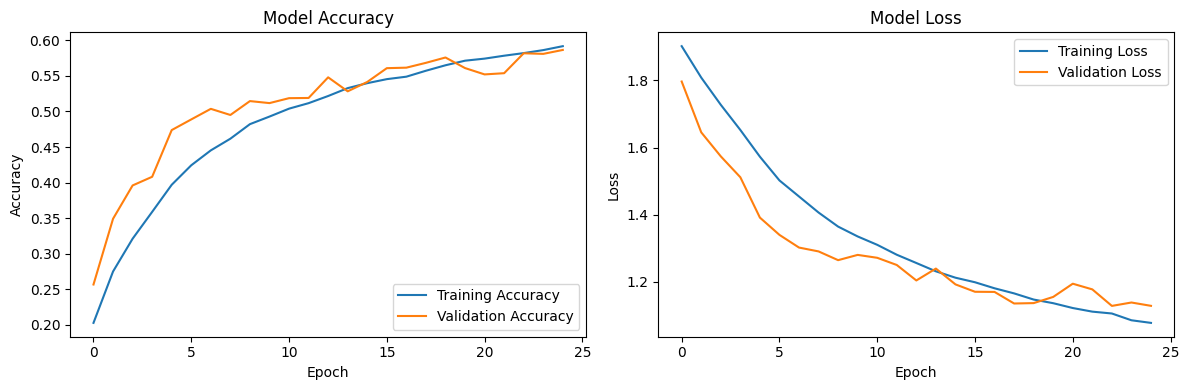

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the model on test data
print("\nEVALUATING BASELINE MODEL:")
test_steps = math.ceil(test_generator.samples / batch_size)
test_loss, test_accuracy = baseline.evaluate(test_generator, steps=test_steps)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


EVALUATING BASELINE MODEL:
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4199 - loss: 1.6693
Test Loss: 1.4046
Test Accuracy: 0.5105


In [ ]:
# Get predictions for the test set
test_generator.reset()
steps = math.ceil(test_generator.samples / batch_size)
y_pred_probs = baseline.predict(test_generator, steps=steps)
y_pred_probs = y_pred_probs[:test_generator.samples]
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = test_generator.classes

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


In [ ]:
# Generate classification report
print("\nCLASSIFICATION REPORT:")
class_names = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Plot confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=16)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label', fontsize=12)
    plt.xlabel('Predicted label', fontsize=12)
    plt.show()


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       angry       0.46      0.38      0.42       300
     disgust       0.80      0.12      0.21       100
        fear       0.51      0.22      0.31       300
       happy       0.62      0.86      0.72       300
     neutral       0.38      0.71      0.50       300
         sad       0.38      0.35      0.36       300
    surprise       0.80      0.66      0.72       300

    accuracy                           0.51      1900
   macro avg       0.56      0.47      0.46      1900
weighted avg       0.54      0.51      0.49      1900



Confusion matrix, without normalization


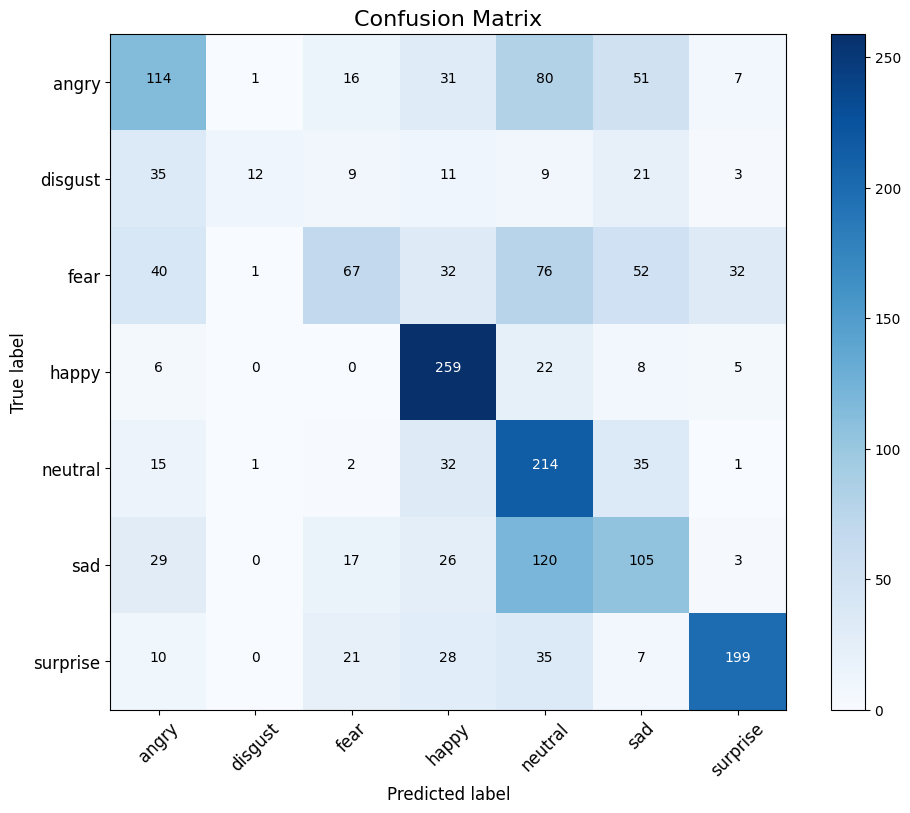

Normalized confusion matrix


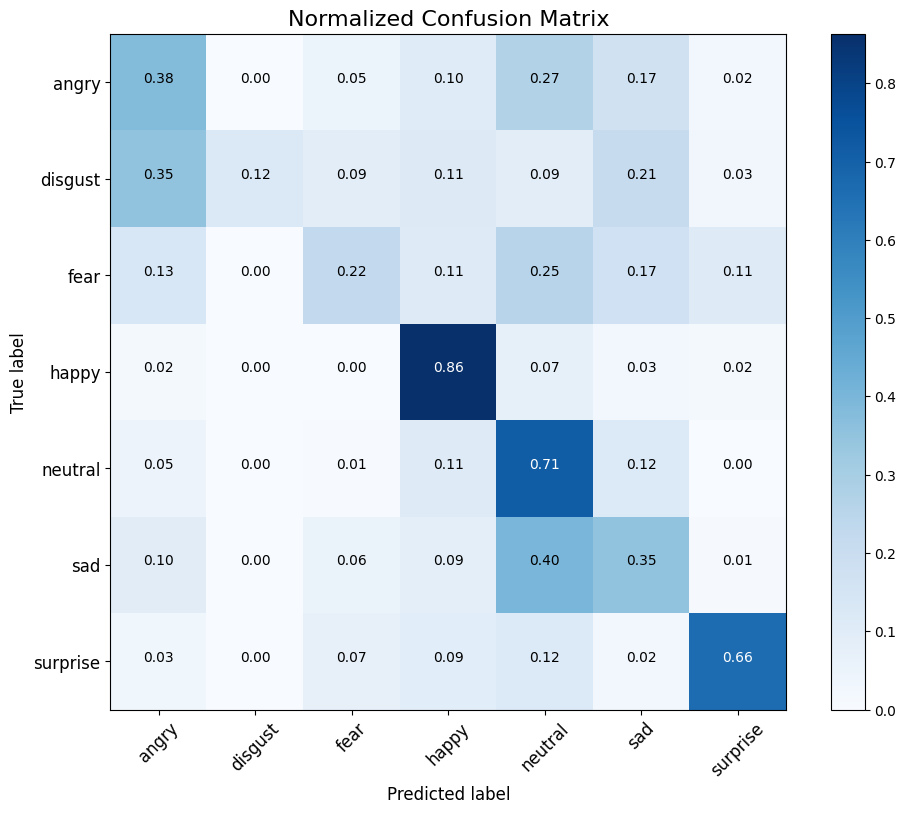

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot non-normalized confusion matrix
plot_confusion_matrix(cm, classes=class_names, title='Confusion Matrix')

# Plot normalized confusion matrix
plot_confusion_matrix(cm, classes=class_names, normalize=True, title='Normalized Confusion Matrix')


SAMPLE PREDICTIONS:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step


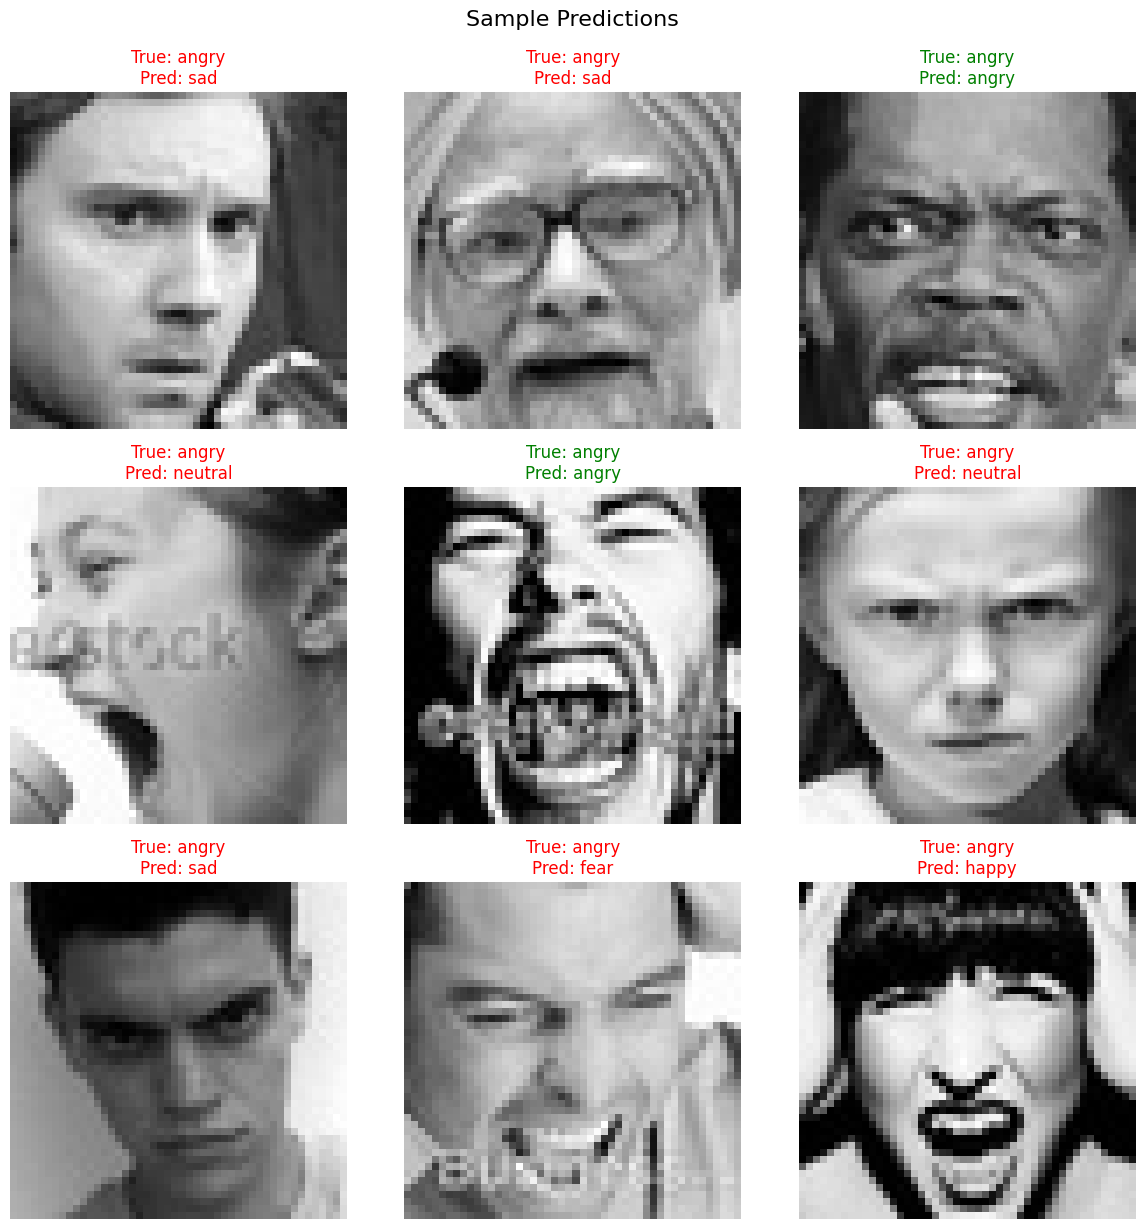

In [ ]:
# Perform inference on sample images
print("\nSAMPLE PREDICTIONS:")

# Get a batch of test images
test_generator.reset()
test_batch = next(test_generator)
test_images, test_labels = test_batch

# Make predictions
predictions = baseline.predict(test_images)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# Display sample predictions
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, ax in enumerate(axes[:min(9, len(test_images))]):
    img = test_images[i].reshape(48, 48)
    true_emotion = class_names[true_classes[i]]
    pred_emotion = class_names[pred_classes[i]]

    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {true_emotion}\nPred: {pred_emotion}",
                 color='green' if true_emotion == pred_emotion else 'red')
    ax.axis('off')

plt.tight_layout()
plt.suptitle('Sample Predictions', fontsize=16, y=1.02)
plt.show()


In [ ]:
# Model performance discussion
print("\nMODEL PERFORMANCE DISCUSSION:")
print("1. Accuracy Analysis:")
print(f"   - Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"   - Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"   - Test Accuracy: {test_accuracy:.4f}")


MODEL PERFORMANCE DISCUSSION:
1. Accuracy Analysis:
   - Training Accuracy: 0.5918
   - Validation Accuracy: 0.5865
   - Test Accuracy: 0.5105


Deeper Model


In [ ]:
# Define model parameters
num_classes = len(emotions)  # 7 emotions
input_shape = (48, 48, 1)    # 48x48 grayscale images

# Define image parameters
image_size = (48, 48)
batch_size = 32

In [ ]:
# Create a balanced deeper CNN model with residual connections
def create_balanced_deeper_model():
    # Input layer
    inputs = Input(shape=input_shape)

    # First Convolutional Block with larger filters
    x = Conv2D(64, kernel_size=(5, 5), padding='same', kernel_regularizer=l2(0.00001))(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(64, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.00001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.15)(x)  # Reduced dropout

    # Second Convolutional Block with residual connection
    x_skip = x
    x = Conv2D(128, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.00001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(128, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.00001))(x)
    x = BatchNormalization()(x)
    # Project skip connection
    x_skip = Conv2D(128, kernel_size=(1, 1), padding='same')(x_skip)
    x = Add()([x, x_skip])  # Add residual connection
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.15)(x)  # Reduced dropout

    # Third Convolutional Block with residual connection
    x_skip = x
    x = Conv2D(256, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.00001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Conv2D(256, kernel_size=(3, 3), padding='same', kernel_regularizer=l2(0.00001))(x)
    x = BatchNormalization()(x)
    # Project skip connection
    x_skip = Conv2D(256, kernel_size=(1, 1), padding='same')(x_skip)
    x = Add()([x, x_skip])  # Add residual connection
    x = Activation('relu')(x)
    x = MaxPooling2D(pool_size=(2, 2))(x)
    x = Dropout(0.15)(x)  # Reduced dropout

    # Flatten the output for fully connected layers
    x = Flatten()(x)

    # First Fully Connected Layer
    x = Dense(512, kernel_regularizer=l2(0.00001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)  # Reduced dropout

    # Second Fully Connected Layer
    x = Dense(256, kernel_regularizer=l2(0.00001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)  # Reduced dropout

    # Third Fully Connected Layer
    x = Dense(128, kernel_regularizer=l2(0.00001))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Dropout(0.25)(x)  # Reduced dropout

    # Output Layer
    outputs = Dense(num_classes, activation='softmax')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs)

    # Compile the model with an appropriate learning rate
    model.compile(
        optimizer=Adam(learning_rate=0.0003),  # Slightly higher initial learning rate
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Create the balanced deeper model
balanced_deeper_model = create_balanced_deeper_model()

# Print model summary
print("BALANCED DEEPER MODEL SUMMARY:")
balanced_deeper_model.summary()

BALANCED DEEPER MODEL SUMMARY:


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 48, 48,    │      1,664 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48, 48,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 48, 48,    │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 24, 24,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 24, 24,    │          0 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 24, 24,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 24, 24,    │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 24, 24,    │      8,320 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │ conv2d_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 24, 24,    │          0 │ add[0][0]       

 Total params: 6,078,023 (23.19 MB)

 Trainable params: 6,074,439 (23.17 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [ ]:
# Create a class weight dictionary to give more importance to problematic classes
class_weights = {
    0: 2.0,  # angry (increased weight to address poor performance)
    1: 4.0,  # disgust (adjusted weight)
    2: 2.5,  # fear (adjusted weight)
    3: 0.7,  # happy (slightly lower weight as it's already performing well)
    4: 1.0,  # neutral
    5: 1.5,  # sad
    6: 1.0   # surprise
}

# Create a checkpoint to save the best model
checkpoint = ModelCheckpoint(
    'best_balanced_deeper_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

In [ ]:
# Add learning rate reduction on plateau with more patience
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.7,  # More gradual reduction
    patience=4,  # More patience
    min_lr=0.00001,
    verbose=1
)

# Add early stopping to prevent unnecessary training
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=8,  # Wait for 8 epochs before stopping
    restore_best_weights=True,
    verbose=1
)

In [ ]:
# Create a balanced data generator with more aggressive augmentation
balanced_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,  # Increased rotation
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2,  # Increased zoom
    shear_range=0.1,  # Added shear
    fill_mode='nearest'
)

# Create balanced training generator
balanced_train_generator = balanced_train_datagen.flow_from_directory(
    os.path.join(dataset_path, 'train'),
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='grayscale',
    shuffle=True
)

Found 26872 images belonging to 7 classes.


In [ ]:
# Train the model
print("\nTRAINING DEEPER MODEL:")
epochs = 40  # Increased number of epochs with early stopping

# Calculate the correct steps_per_epoch to avoid the "ran out of data" warning
steps_per_epoch = math.ceil(balanced_train_generator.samples / batch_size)
validation_steps = math.ceil(validation_generator.samples / batch_size)

# Record start time for training duration measurement
start_time = time.time()

# Use the balanced training generator
history_balanced = balanced_deeper_model.fit(
    balanced_train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    class_weight=class_weights,  # Apply class weights
    callbacks=[checkpoint, reduce_lr, early_stopping],
    verbose=1
)

# Calculate training time
training_time = time.time() - start_time
print(f"\nTraining completed in {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
# Save the final model
balanced_deeper_model.save('final_balanced_deeper_model.h5')
print("Final model saved as 'final_balanced_deeper_model.h5'")


TRAINING DEEPER MODEL:
Epoch 1/40


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.1629 - loss: 3.1187
Epoch 1: val_accuracy improved from -inf to 0.21016, saving model to best_balanced_deeper_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 51s 41ms/step - accuracy: 0.1629 - loss: 3.1181 - val_accuracy: 0.2102 - val_loss: 1.8436 - learning_rate: 3.0000e-04
Epoch 2/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1814 - loss: 2.6174
Epoch 2: val_accuracy did not improve from 0.21016
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.1814 - loss: 2.6174 - val_accuracy: 0.1854 - val_loss: 1.9199 - learning_rate: 3.0000e-04
Epoch 3/40
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.1906 - loss: 2.5422
Epoch 3: val_accuracy improved from 0.21016 to 0.22035, saving model to best_balanced_deeper_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.1906 - loss: 2.5422 - val_accuracy: 0.2204 - val_loss: 1.8764 - learning_rate: 3.0000e-04
Epoch 4/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2141 - loss: 2.4968
Epoch 4: val_accuracy improved from 0.22035 to 0.29253, saving model to best_balanced_deeper_model.h5


...


Epoch 32: ReduceLROnPlateau reducing learning rate to 0.00021000000997446476.
840/840 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.5841 - loss: 1.6937 - val_accuracy: 0.6418 - val_loss: 1.0631 - learning_rate: 3.0000e-04
Epoch 33/40
838/840 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6004 - loss: 1.6432
Epoch 33: val_accuracy did not improve from 0.64181
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.6004 - loss: 1.6432 - val_accuracy: 0.6347 - val_loss: 1.0643 - learning_rate: 2.1000e-04
Epoch 34/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6032 - loss: 1.6266
Epoch 34: val_accuracy did not improve from 0.64181
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.6032 - loss: 1.6266 - val_accuracy: 0.6388 - val_loss: 1.0768 - learning_rate: 2.1000e-04
Epoch 35/40
838/840 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6075 - loss: 1.6107
Epoch 35: val_accuracy improved from 0.64181 to 0.64817, saving model to best_balanced_deeper_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.6075 - loss: 1.6107 - val_accuracy: 0.6482 - val_loss: 1.0448 - learning_rate: 2.1000e-04
Epoch 36/40
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6020 - loss: 1.6202
Epoch 36: val_accuracy did not improve from 0.64817
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.6020 - loss: 1.6202 - val_accuracy: 0.6261 - val_loss: 1.1005 - learning_rate: 2.1000e-04
Epoch 37/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6130 - loss: 1.5980
Epoch 37: val_accuracy improved from 0.64817 to 0.65044, saving model to best_balanced_deeper_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.6130 - loss: 1.5980 - val_accuracy: 0.6504 - val_loss: 1.0550 - learning_rate: 2.1000e-04
Epoch 38/40
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6181 - loss: 1.5823
Epoch 38: val_accuracy did not improve from 0.65044
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.6181 - loss: 1.5824 - val_accuracy: 0.6410 - val_loss: 1.0708 - learning_rate: 2.1000e-04
Epoch 39/40
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6156 - loss: 1.5823
Epoch 39: val_accuracy did not improve from 0.65044

Epoch 39: ReduceLROnPlateau reducing learning rate to 0.00014700000901939346.
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.6156 - loss: 1.5823 - val_accuracy: 0.6468 - val_loss: 1.0515 - learning_rate: 2.1000e-04
Epoch 40/40
838/840 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6119 - loss: 1.5853
Epoch 40: val_accuracy improved from 0.65044 to 0.65242, saving model to best_balanced_deeper_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.6119 - loss: 1.5852 - val_accuracy: 0.6524 - val_loss: 1.0406 - learning_rate: 1.4700e-04
Restoring model weights from the end of the best epoch: 40.



Training completed in 923.99 seconds (15.40 minutes)
Final model saved as 'final_balanced_deeper_model.h5'


In [ ]:
# Load the best model for evaluation
from tensorflow.keras.models import load_model
best_model = load_model('best_balanced_deeper_model.h5')


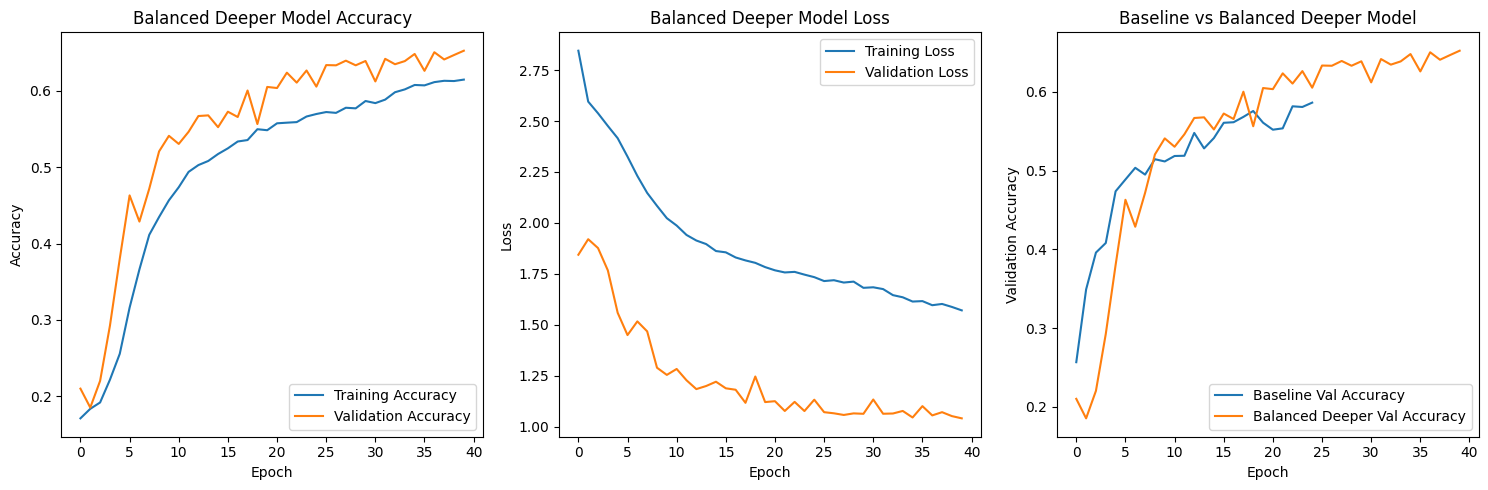

In [ ]:
# Plot training history
plt.figure(figsize=(15, 5))

# Plot training & validation accuracy
plt.subplot(1, 3, 1)
plt.plot(history_balanced.history['accuracy'], label='Training Accuracy')
plt.plot(history_balanced.history['val_accuracy'], label='Validation Accuracy')
plt.title('Balanced Deeper Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training & validation loss
plt.subplot(1, 3, 2)
plt.plot(history_balanced.history['loss'], label='Training Loss')
plt.plot(history_balanced.history['val_loss'], label='Validation Loss')
plt.title('Balanced Deeper Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Compare with baseline model
plt.subplot(1, 3, 3)
plt.plot(history.history['val_accuracy'], label='Baseline Val Accuracy')
plt.plot(history_balanced.history['val_accuracy'], label='Balanced Deeper Val Accuracy')
plt.title('Baseline vs Balanced Deeper Model')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

In [ ]:
# Evaluate the model on test data
print("\nEVALUATING BALANCED DEEPER MODEL:")
test_steps = math.ceil(test_generator.samples / batch_size)
test_loss, test_accuracy = best_model.evaluate(test_generator, steps=test_steps)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Get predictions for the test set
test_generator.reset()
steps = math.ceil(test_generator.samples / batch_size)
y_pred_probs = best_model.predict(test_generator, steps=steps)
y_pred_probs = y_pred_probs[:test_generator.samples]
y_pred = np.argmax(y_pred_probs, axis=1)

# Get true labels
y_true = test_generator.classes


EVALUATING BALANCED DEEPER MODEL:
60/60 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.6106 - loss: 1.1566
Test Loss: 1.1573
Test Accuracy: 0.6111
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


In [ ]:
# Generate classification report
print("\nCLASSIFICATION REPORT:")
class_names = list(test_generator.class_indices.keys())
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Plot confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=16)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label', fontsize=12)
    plt.xlabel('Predicted label', fontsize=12)
    plt.show()


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       angry       0.55      0.64      0.59       300
     disgust       0.79      0.59      0.67       100
        fear       0.51      0.38      0.44       300
       happy       0.83      0.82      0.82       300
     neutral       0.46      0.75      0.57       300
         sad       0.51      0.42      0.46       300
    surprise       0.88      0.66      0.76       300

    accuracy                           0.61      1900
   macro avg       0.65      0.61      0.62      1900
weighted avg       0.63      0.61      0.61      1900



Confusion matrix, without normalization


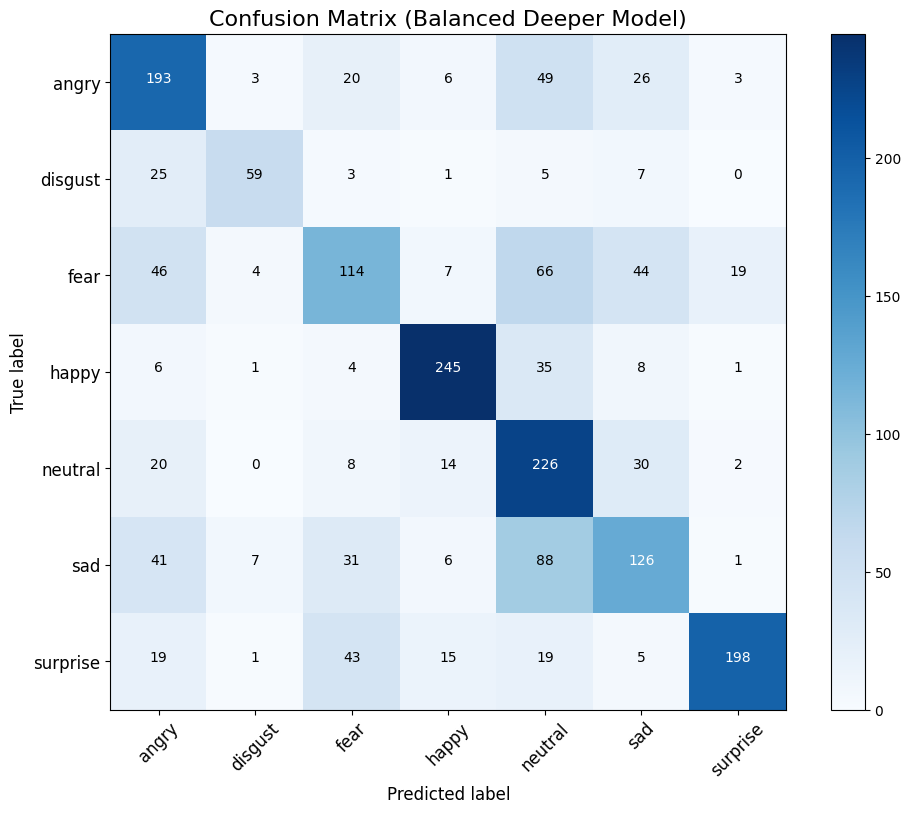

Normalized confusion matrix


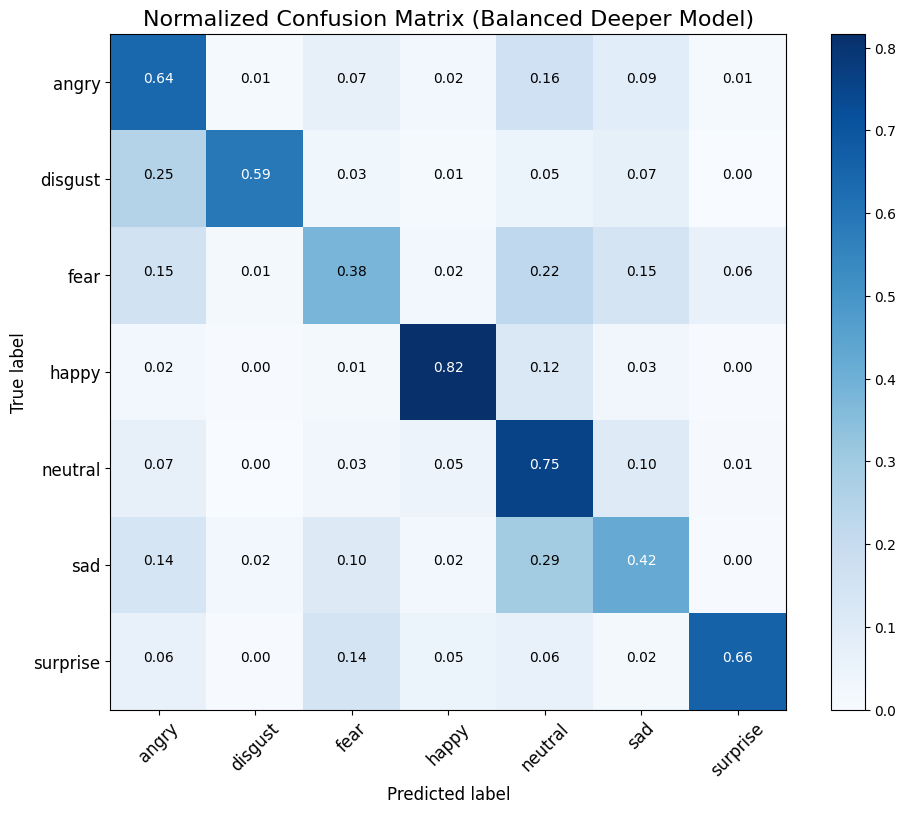

In [ ]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot non-normalized confusion matrix
plot_confusion_matrix(cm, classes=class_names, title='Confusion Matrix (Balanced Deeper Model)')

# Plot normalized confusion matrix
plot_confusion_matrix(cm, classes=class_names, normalize=True, title='Normalized Confusion Matrix (Balanced Deeper Model)')



SAMPLE PREDICTIONS:
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 725ms/step


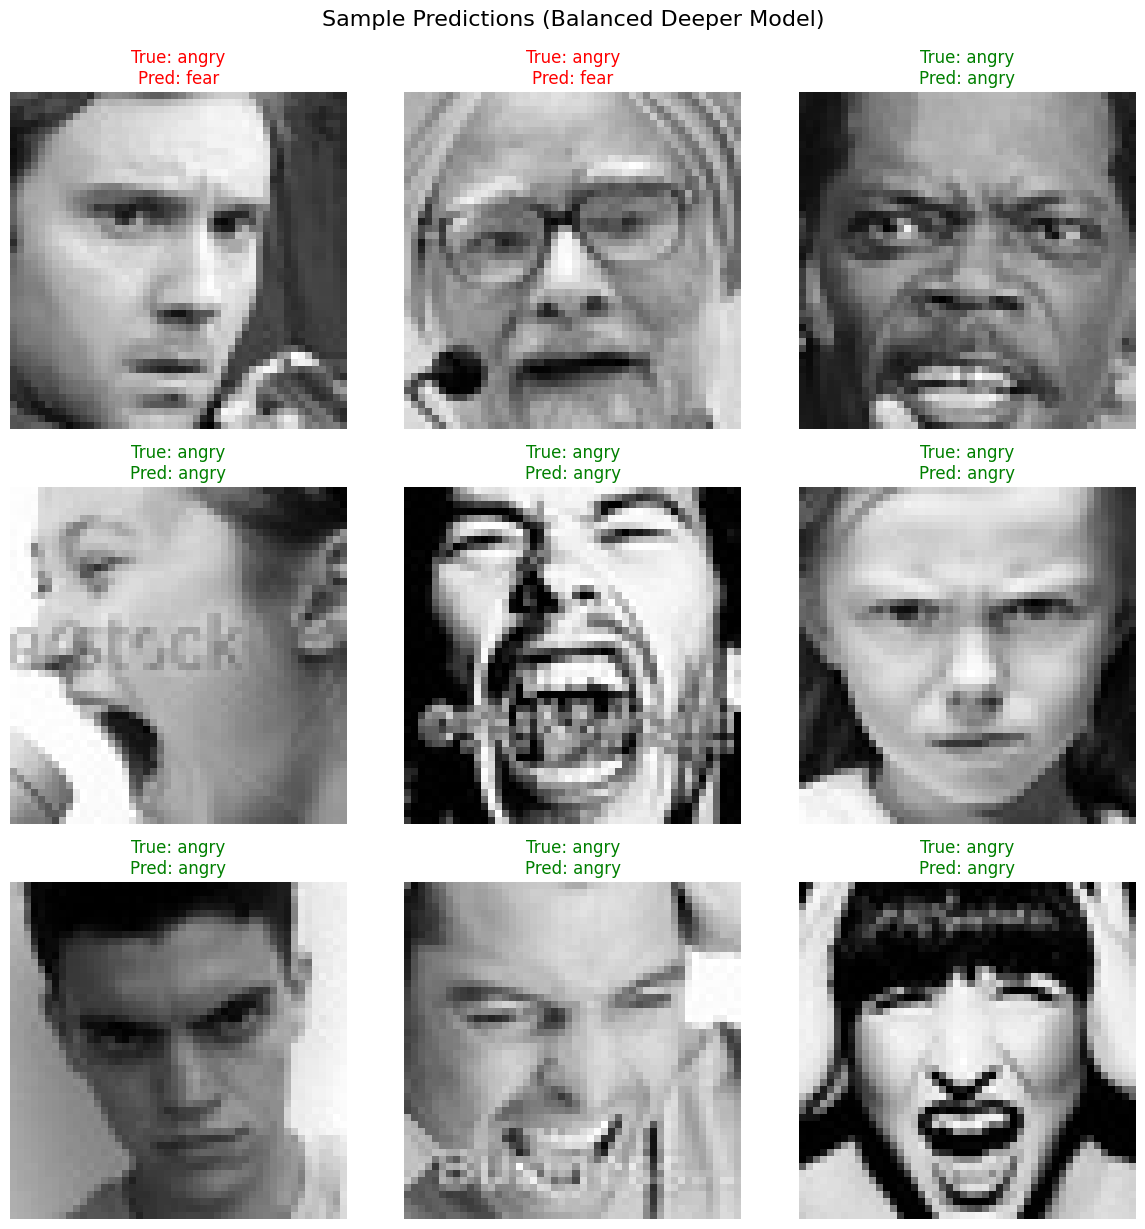

In [ ]:
# Perform inference on sample images
print("\nSAMPLE PREDICTIONS:")

# Get a batch of test images
test_generator.reset()
test_batch = next(test_generator)
test_images, test_labels = test_batch

# Make predictions
predictions = best_model.predict(test_images)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# Display sample predictions
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for i, ax in enumerate(axes[:min(9, len(test_images))]):
    img = test_images[i].reshape(48, 48)
    true_emotion = class_names[true_classes[i]]
    pred_emotion = class_names[pred_classes[i]]

    ax.imshow(img, cmap='gray')
    ax.set_title(f"True: {true_emotion}\nPred: {pred_emotion}",
                 color='green' if true_emotion == pred_emotion else 'red')
    ax.axis('off')

plt.tight_layout()
plt.suptitle('Sample Predictions (Balanced Deeper Model)', fontsize=16, y=1.02)
plt.show()

In [ ]:
# Model performance comparison
print("\nMODEL PERFORMANCE COMPARISON:")
print("1. Architecture Comparison:")
print("   Baseline Model: 3 convolutional layers, 3 fully connected layers")
print("   Balanced Deeper Model: 6 convolutional layers with residual connections, 3 fully connected layers")
print("   Regularization in Balanced Deeper Model: Dropout, BatchNormalization, L2 regularization")
print("   Added features: Residual connections, learning rate scheduling, class weighting, early stopping")

print("\n2. Accuracy Comparison:")
print(f"   - Baseline Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"   - Baseline Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")
print(f"   - Balanced Deeper Model Training Accuracy: {history_balanced.history['accuracy'][-1]:.4f}")
print(f"   - Balanced Deeper Model Validation Accuracy: {history_balanced.history['val_accuracy'][-1]:.4f}")

print("\n3. Training Time Comparison:")
print(f"   - Balanced Deeper Model Training Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")
print("   - The balanced deeper model takes longer to train due to increased complexity")


MODEL PERFORMANCE COMPARISON:
1. Architecture Comparison:
   Baseline Model: 3 convolutional layers, 3 fully connected layers
   Balanced Deeper Model: 6 convolutional layers with residual connections, 3 fully connected layers
   Regularization in Balanced Deeper Model: Dropout, BatchNormalization, L2 regularization
   Added features: Residual connections, learning rate scheduling, class weighting, early stopping

2. Accuracy Comparison:
   - Baseline Training Accuracy: 0.5918
   - Baseline Validation Accuracy: 0.5865
   - Balanced Deeper Model Training Accuracy: 0.6146
   - Balanced Deeper Model Validation Accuracy: 0.6524

3. Training Time Comparison:
   - Balanced Deeper Model Training Time: 923.99 seconds (15.40 minutes)
   - The balanced deeper model takes longer to train due to increased complexity


SGD MODEL SUMMARY:


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 48, 48,    │      1,664 │ input_layer_2[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_11[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_9        │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 48, 48,    │     36,928 │ activation_9[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48, 48,    │        256 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_10       │ (None, 48, 48,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_6     │ (None, 24, 24,    │          0 │ activation_10[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 24, 24,    │          0 │ max_pooling2d_6[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 24, 24,    │     73,856 │ dropout_6[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_11       │ (None, 24, 24,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 24, 24,    │    147,584 │ activation_11[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 24, 24,    │        512 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 24, 24,    │      8,320 │ dropout_6[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 24,    │          0 │ batch_normalizat… │
│                     │ 128)              │            │ conv2d_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_12       │ (None, 24, 24,    │          0 │ add_2[0][0]     

 Total params: 6,078,023 (23.19 MB)

 Trainable params: 6,074,439 (23.17 MB)

...

840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.5555 - loss: 1.7207 - val_accuracy: 0.6183 - val_loss: 1.0688 - learning_rate: 0.0070
Epoch 29/40
838/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5600 - loss: 1.7026
Epoch 29: val_accuracy did not improve from 0.61831
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.5600 - loss: 1.7026 - val_accuracy: 0.6012 - val_loss: 1.0973 - learning_rate: 0.0070
Epoch 30/40
838/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5599 - loss: 1.7187
Epoch 30: val_accuracy did not improve from 0.61831
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.5599 - loss: 1.7187 - val_accuracy: 0.6057 - val_loss: 1.0970 - learning_rate: 0.0070
Epoch 31/40
838/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5696 - loss: 1.7011
Epoch 31: val_accuracy did not improve from 0.61831
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.5696 - loss: 1.7010 - val_accuracy: 0.5841 - val_loss: 1.1225 - learning_rate: 0.0070
Epoch 32

840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.5711 - loss: 1.6903 - val_accuracy: 0.6312 - val_loss: 1.0268 - learning_rate: 0.0070
Epoch 33/40
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5748 - loss: 1.6718
Epoch 33: val_accuracy did not improve from 0.63119
840/840 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.5748 - loss: 1.6718 - val_accuracy: 0.6289 - val_loss: 1.0289 - learning_rate: 0.0070
Epoch 34/40
838/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5779 - loss: 1.6582
Epoch 34: val_accuracy did not improve from 0.63119
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.5779 - loss: 1.6582 - val_accuracy: 0.6210 - val_loss: 1.0710 - learning_rate: 0.0070
Epoch 35/40
840/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5811 - loss: 1.6476
Epoch 35: val_accuracy did not improve from 0.63119
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.5811 - loss: 1.6476 - val_accuracy: 0.6122 - val_loss: 1.0647 - learning_rate: 0.0070
Epoch 36

840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.5837 - loss: 1.6315 - val_accuracy: 0.6452 - val_loss: 0.9995 - learning_rate: 0.0049
Epoch 38/40
839/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5977 - loss: 1.5977
Epoch 38: val_accuracy did not improve from 0.64520
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.5977 - loss: 1.5977 - val_accuracy: 0.6277 - val_loss: 1.0477 - learning_rate: 0.0049
Epoch 39/40
838/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5937 - loss: 1.6097
Epoch 39: val_accuracy did not improve from 0.64520
840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.5937 - loss: 1.6097 - val_accuracy: 0.6217 - val_loss: 1.0568 - learning_rate: 0.0049
Epoch 40/40
838/840 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5970 - loss: 1.5809
Epoch 40: val_accuracy improved from 0.64520 to 0.64534, saving model to best_sgd_model.h5


840/840 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.5970 - loss: 1.5809 - val_accuracy: 0.6453 - val_loss: 1.0017 - learning_rate: 0.0049
Restoring model weights from the end of the best epoch: 40.

SGD training completed in 923.20 seconds (15.39 minutes)



EVALUATING SGD MODEL ON TEST DATA:
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.5877 - loss: 1.1426
SGD Test Loss: 1.0959
SGD Test Accuracy: 0.5989


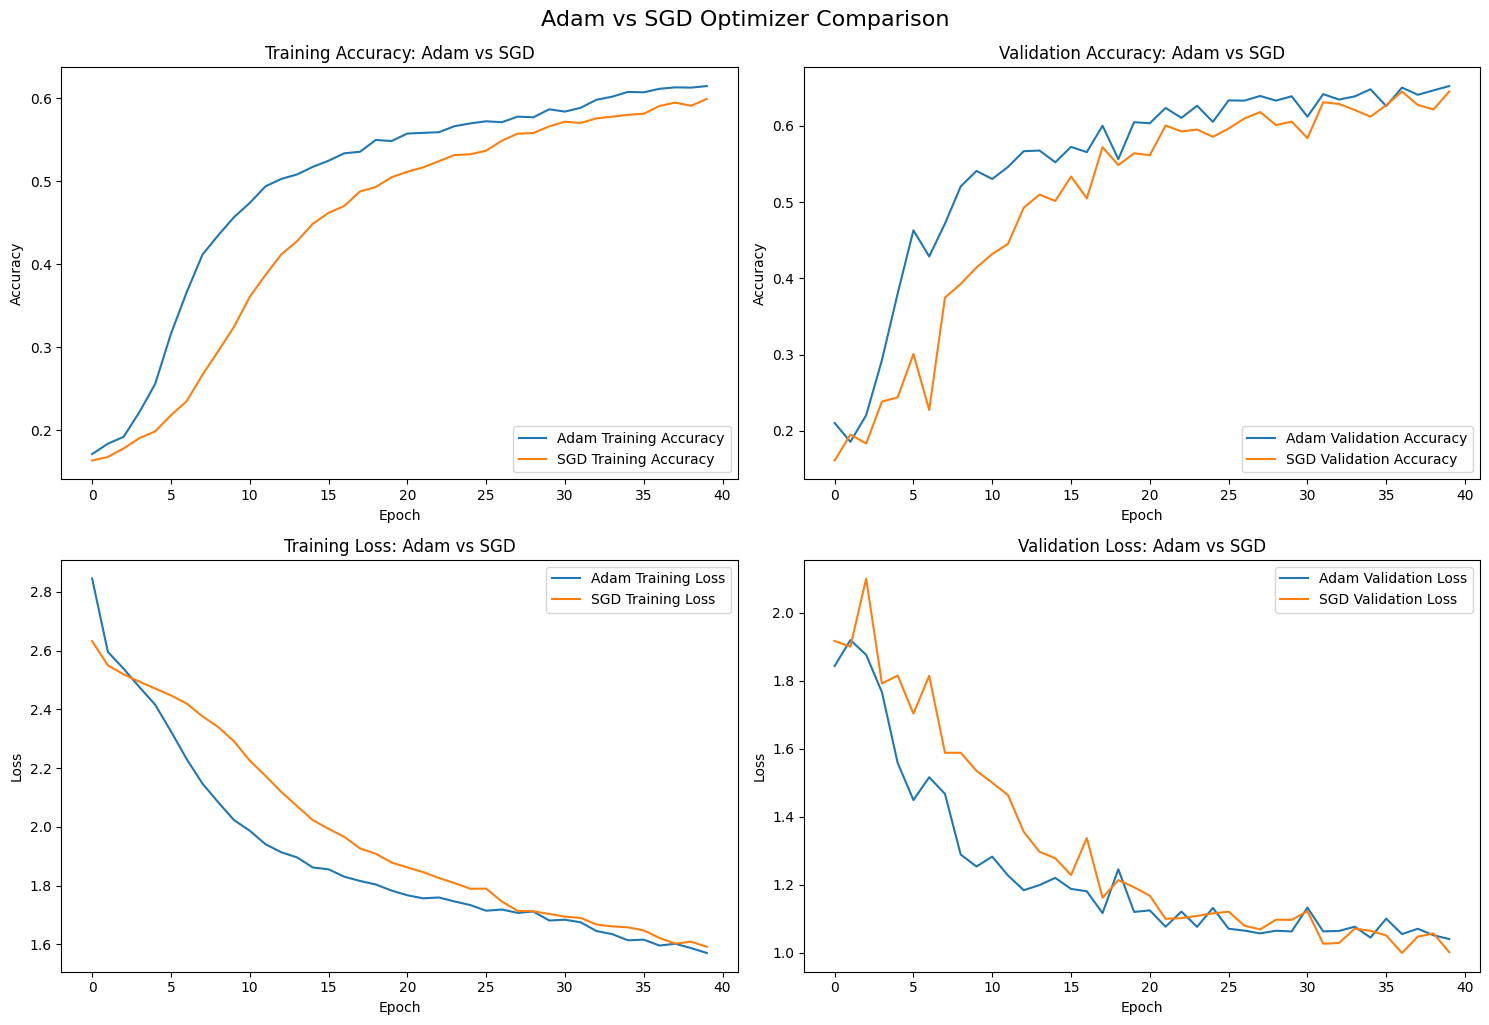

In [ ]:
# Create a copy of the balanced deeper model with SGD optimizer
def create_balanced_deeper_model_sgd():
    # Use the same architecture as the balanced deeper model
    model = create_balanced_deeper_model()

    # Recompile with SGD optimizer
    model.compile(
        optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),  # SGD with momentum
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Create the SGD model
sgd_model = create_balanced_deeper_model_sgd()
print("SGD MODEL SUMMARY:")
sgd_model.summary()

# Create checkpoint for SGD model
sgd_checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_sgd_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Add learning rate reduction for SGD
sgd_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.7,
    patience=4,
    min_lr=0.0001,
    verbose=1
)

# Add early stopping for SGD
sgd_early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# Train the SGD model
print("\nTRAINING BALANCED DEEPER MODEL WITH SGD:")
epochs = 40

# Calculate steps
steps_per_epoch = math.ceil(balanced_train_generator.samples / batch_size)
validation_steps = math.ceil(validation_generator.samples / batch_size)

# Record start time for SGD training
sgd_start_time = time.time()

# Train with SGD
history_sgd = sgd_model.fit(
    balanced_train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=validation_steps,
    class_weight=class_weights,  # Same class weights as Adam model
    callbacks=[sgd_checkpoint, sgd_reduce_lr, sgd_early_stopping],
    verbose=1
)

# Calculate SGD training time
sgd_training_time = time.time() - sgd_start_time
print(f"\nSGD training completed in {sgd_training_time:.2f} seconds ({sgd_training_time/60:.2f} minutes)")

# Load the best SGD model
best_sgd_model = tf.keras.models.load_model('best_sgd_model.h5')

# Evaluate SGD model on test data
print("\nEVALUATING SGD MODEL ON TEST DATA:")
test_steps = math.ceil(test_generator.samples / batch_size)
sgd_test_loss, sgd_test_accuracy = best_sgd_model.evaluate(test_generator, steps=test_steps)
print(f"SGD Test Loss: {sgd_test_loss:.4f}")
print(f"SGD Test Accuracy: {sgd_test_accuracy:.4f}")

# Compare Adam vs SGD training curves
plt.figure(figsize=(15, 10))

# Plot training accuracy comparison
plt.subplot(2, 2, 1)
plt.plot(history_balanced.history['accuracy'], label='Adam Training Accuracy')
plt.plot(history_sgd.history['accuracy'], label='SGD Training Accuracy')
plt.title('Training Accuracy: Adam vs SGD')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot validation accuracy comparison
plt.subplot(2, 2, 2)
plt.plot(history_balanced.history['val_accuracy'], label='Adam Validation Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='SGD Validation Accuracy')
plt.title('Validation Accuracy: Adam vs SGD')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Plot training loss comparison
plt.subplot(2, 2, 3)
plt.plot(history_balanced.history['loss'], label='Adam Training Loss')
plt.plot(history_sgd.history['loss'], label='SGD Training Loss')
plt.title('Training Loss: Adam vs SGD')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

# Plot validation loss comparison
plt.subplot(2, 2, 4)
plt.plot(history_balanced.history['val_loss'], label='Adam Validation Loss')
plt.plot(history_sgd.history['val_loss'], label='SGD Validation Loss')
plt.title('Validation Loss: Adam vs SGD')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.suptitle('Adam vs SGD Optimizer Comparison', fontsize=16, y=1.02)
plt.show()

# Compare convergence speed
adam_epochs_to_best = np.argmax(history_balanced.history['val_accuracy'])
sgd_epochs_to_best = np.argmax(history_sgd.history['val_accuracy'])

# Compare final performance
adam_best_val_acc = np.max(history_balanced.history['val_accuracy'])
sgd_best_val_acc = np.max(history_sgd.history['val_accuracy'])

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step


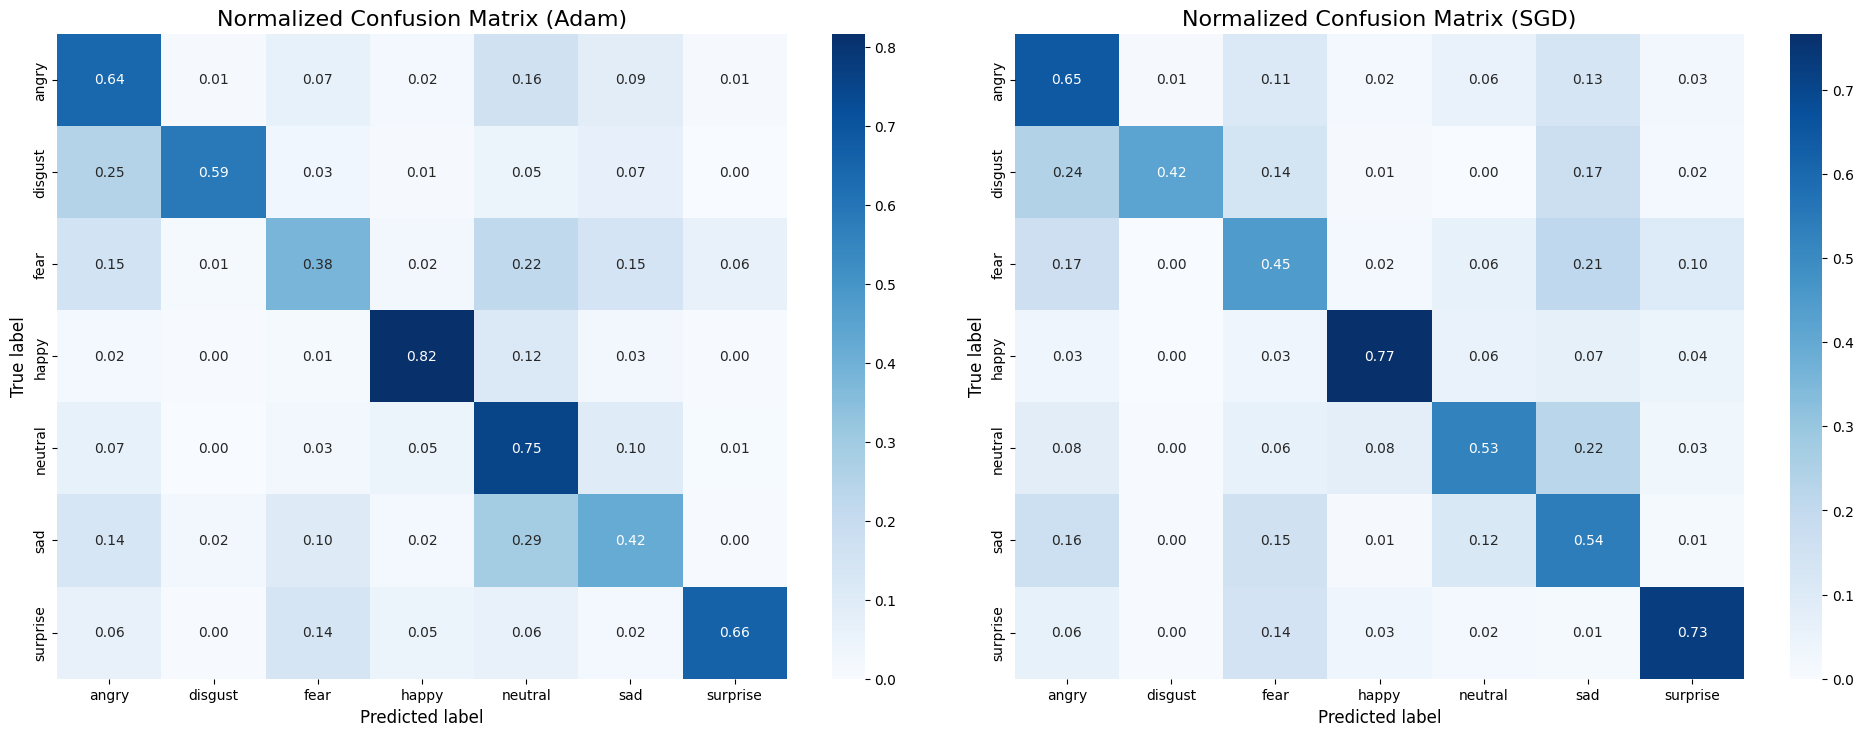

In [ ]:
# Confusion Matrix Visualization for Adam vs SGD Comparison
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import itertools

# Function to plot confusion matrix
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, fontsize=16)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45, fontsize=12)
    plt.yticks(tick_marks, classes, fontsize=12)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label', fontsize=12)
    plt.xlabel('Predicted label', fontsize=12)

# Get predictions for Adam model
test_generator.reset()
steps = np.ceil(test_generator.samples / batch_size).astype(int)
adam_y_pred_probs = best_model.predict(test_generator, steps=steps)
adam_y_pred_probs = adam_y_pred_probs[:test_generator.samples]
adam_y_pred = np.argmax(adam_y_pred_probs, axis=1)

# Get predictions for SGD model
test_generator.reset()
sgd_y_pred_probs = best_sgd_model.predict(test_generator, steps=steps)
sgd_y_pred_probs = sgd_y_pred_probs[:test_generator.samples]
sgd_y_pred = np.argmax(sgd_y_pred_probs, axis=1)

# Get true labels
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Compute confusion matrices
adam_cm = confusion_matrix(y_true, adam_y_pred)
sgd_cm = confusion_matrix(y_true, sgd_y_pred)

# Plot normalized confusion matrices side by side
plt.figure(figsize=(20, 8))

# Adam confusion matrix
plt.subplot(1, 2, 1)
sns.heatmap(adam_cm.astype('float') / adam_cm.sum(axis=1)[:, np.newaxis],
            annot=True,
            fmt='.2f',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Normalized Confusion Matrix (Adam)', fontsize=16)
plt.ylabel('True label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)

# SGD confusion matrix
plt.subplot(1, 2, 2)
sns.heatmap(sgd_cm.astype('float') / sgd_cm.sum(axis=1)[:, np.newaxis],
            annot=True,
            fmt='.2f',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Normalized Confusion Matrix (SGD)', fontsize=16)
plt.ylabel('True label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)

plt.tight_layout(pad=3)
plt.show()

In [ ]:
# Get true labels and predictions
true_labels = []
predicted_probs = []
for _ in range(test_steps):
    X_batch, y_batch = next(test_generator)
    true_labels.extend(np.argmax(y_batch, axis=1))
    predicted_probs.extend(best_sgd_model.predict(X_batch, verbose=0))

true_labels = np.array(true_labels)
predicted_labels = np.argmax(predicted_probs, axis=1)

# Classification Report
print("\nSGD MODEL CLASSIFICATION REPORT:")
class_names = list(test_generator.class_indices.keys())
print(classification_report(true_labels, predicted_labels, target_names=class_names))


SGD MODEL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       angry       0.52      0.65      0.58       300
     disgust       0.88      0.42      0.57       100
        fear       0.45      0.45      0.45       300
       happy       0.83      0.77      0.80       300
     neutral       0.63      0.53      0.57       300
         sad       0.44      0.54      0.48       300
    surprise       0.77      0.73      0.75       300

    accuracy                           0.60      1900
   macro avg       0.64      0.58      0.60      1900
weighted avg       0.62      0.60      0.60      1900



In [ ]:
!pip install opencv-python
!pip install tensorflow

In [ ]:
# Import necessary libraries
import os
import zipfile
import glob
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import defaultdict
import cv2
from sklearn.metrics import classification_report
import tensorflow as tf , tensorflow
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras import optimizers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.utils import to_categorical
from sklearn.utils import class_weight

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
# Step 1: Extract the zip file
zip_file_path = '/content/facial expression classification.zip'
extracted_dir = '/content/facial_expression'
os.makedirs(extracted_dir, exist_ok=True)

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extracted_dir)

print(f"Extracted files to: {extracted_dir}")

# Define the path to your dataset
dataset_path = os.path.join(extracted_dir, 'facial expression classification')

# Define the splits and classes
splits = ['train', 'test', 'validation']
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

Extracted files to: /content/facial_expression


In [ ]:
# Step 1: Analyze class distribution in training set
train_dir = os.path.join(dataset_path, 'train')
val_dir = os.path.join(dataset_path, 'validation')
test_dir = os.path.join(dataset_path, 'test')

In [ ]:
# Define constants
img_height, img_width = 96, 96
BATCH_SIZE = 32
num_classes = 7
classes = ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

In [ ]:
# Step 3: Remove corrupted images
from collections import defaultdict

# Initialize image_counts as a defaultdict of defaultdict of int
image_counts = defaultdict(lambda: defaultdict(int))

def check_image(file_path):
    try:
        img = Image.open(file_path)
        img.verify()  # Verify if the image is valid
        return True
    except (IOError, SyntaxError, Image.UnidentifiedImageError):
        return False

for split in splits:
    for cls in classes:
        cls_path = os.path.join(dataset_path, split, cls)
        if os.path.exists(cls_path):
            image_files = glob.glob(os.path.join(cls_path, '*.*'))
            for img_path in image_files:
                if not check_image(img_path):
                    print(f"Removing corrupted image: {img_path}")
                    os.remove(img_path)
            image_counts[split][cls] = len(glob.glob(os.path.join(cls_path, '*.*')))
            print(f"Updated {split}/{cls}: {image_counts[split][cls]} images")

Removing corrupted image: /content/facial_expression/facial expression classification/train/angry/6171.jpg
Removing corrupted image: /content/facial_expression/facial expression classification/train/angry/26089.jpg
Removing corrupted image: /content/facial_expression/facial expression classification/train/angry/15395.jpg
Removing corrupted image: /content/facial_expression/facial expression classification/train/angry/18369.jpg
Removing corrupted image: /content/facial_expression/facial expression classification/train/angry/8887.jpg
Removing corrupted image: /content/facial_expression/facial expression classification/train/angry/34380.jpg
Removing corrupted image: /content/facial_expression/facial expression classification/train/angry/8149.jpg
Updated train/angry: 3686 images
Removing corrupted image: /content/facial_expression/facial expression classification/train/disgust/10538.jpg
Removing corrupted image: /content/facial_expression/facial expression classification/train/disgust/1536

In [ ]:
# Custom augmentation for minority classes (e.g., disgust)
minority_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.3,
    height_shift_range=0.3,
    zoom_range=0.3,
    horizontal_flip=True,
    vertical_flip=True,  # Add vertical flip for more variety
    brightness_range=[0.5, 1.5],  # Add brightness variation
    fill_mode='nearest'
)

# Data augmentation for training (applied to all classes)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)


In [ ]:
# Only rescaling for validation/test
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)


In [ ]:
# Create data generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)

Found 26872 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.
Found 1900 images belonging to 7 classes.


In [ ]:
# Compute class weights to handle imbalance
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

# Convert to dictionary for Keras
class_weights_dict = dict(enumerate(class_weights))

# Print class weights for verification
print("Class Weights:", class_weights_dict)

Class Weights: {0: np.float64(1.0414696535152315), 1: np.float64(11.668258792878854), 2: np.float64(1.0112900797832305), 3: np.float64(0.559844996770766), 4: np.float64(0.8211459129106188), 5: np.float64(0.8289477743159454), 6: np.float64(1.3246573991915607)}


In [ ]:
from tensorflow.keras.applications import MobileNetV2

# Load MobileNetV2 model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(img_height, img_width, 3), pooling='avg')

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
# Freeze base model layers, keep batch norm trainable
FROZEN_LAYER_NUM = 120  # Freeze up to layer 120 out of ~155
for layer in base_model.layers[:FROZEN_LAYER_NUM]:
    if not isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True
for layer in base_model.layers[FROZEN_LAYER_NUM:]:
    layer.trainable = True

In [ ]:
# Add custom top layers
x = base_model.output
x = Flatten()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(num_classes, activation='softmax')(x)

In [ ]:
# Create final model
model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Define callbacks
lr_scheduler = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
checkpoint = ModelCheckpoint(
    'best_resnet50_fer2013.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 3,833,927 (14.63 MB)

 Trainable params: 3,218,119 (12.28 MB)

 Non-trainable params: 615,808 (2.35 MB)

In [ ]:
# Train model (Phase 1: Feature Extraction)
print("\nTRANSFER LEARNING MODEL TRAINING: Phase 1 - Feature Extraction")
history_phase1 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,  # Use lowercase batch_size (updated constant)
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=20,
    callbacks=[lr_scheduler, early_stopping, checkpoint],
    class_weight=class_weights_dict,  # Use the dictionary, not the array
    verbose=1
)


TRANSFER LEARNING MODEL TRAINING: Phase 1 - Feature Extraction
Epoch 1/20
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.2318 - loss: 1.9476
Epoch 1: val_accuracy improved from -inf to 0.39659, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 130s 108ms/step - accuracy: 0.2319 - loss: 1.9474 - val_accuracy: 0.3966 - val_loss: 1.5831 - learning_rate: 1.0000e-04
Epoch 2/20
  1/839 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.5000 - loss: 1.4569

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:107: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy did not improve from 0.39659
839/839 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.5000 - loss: 1.4569 - val_accuracy: 0.3952 - val_loss: 1.5846 - learning_rate: 1.0000e-04
Epoch 3/20
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3602 - loss: 1.6092
Epoch 3: val_accuracy improved from 0.39659 to 0.39815, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 71s 85ms/step - accuracy: 0.3602 - loss: 1.6092 - val_accuracy: 0.3982 - val_loss: 1.5967 - learning_rate: 1.0000e-04
Epoch 4/20
  1/839 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.4688 - loss: 1.8269
Epoch 4: val_accuracy did not improve from 0.39815
839/839 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4688 - loss: 1.8269 - val_accuracy: 0.3977 - val_loss: 1.5994 - learning_rate: 1.0000e-04
Epoch 5/20
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.3999 - loss: 1.5263
Epoch 5: val_accuracy improved from 0.39815 to 0.40043, saving model to best_resnet50_fer2013.h5


...

839/839 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.4752 - loss: 1.3067 - val_accuracy: 0.4903 - val_loss: 1.3243 - learning_rate: 5.0000e-05
Epoch 14/20
  1/839 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - accuracy: 0.6875 - loss: 0.8562
Epoch 14: val_accuracy did not improve from 0.49034
839/839 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6875 - loss: 0.8562 - val_accuracy: 0.4901 - val_loss: 1.3265 - learning_rate: 5.0000e-05
Epoch 15/20
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.4895 - loss: 1.3106
Epoch 15: val_accuracy improved from 0.49034 to 0.49205, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 71s 85ms/step - accuracy: 0.4895 - loss: 1.3106 - val_accuracy: 0.4920 - val_loss: 1.3138 - learning_rate: 5.0000e-05
Epoch 16/20
  1/839 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.5625 - loss: 1.0633
Epoch 16: val_accuracy did not improve from 0.49205
839/839 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5625 - loss: 1.0633 - val_accuracy: 0.4920 - val_loss: 1.3133 - learning_rate: 5.0000e-05
Epoch 17/20
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.4954 - loss: 1.2579
Epoch 17: val_accuracy improved from 0.49205 to 0.51264, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.4954 - loss: 1.2579 - val_accuracy: 0.5126 - val_loss: 1.2635 - learning_rate: 5.0000e-05
Epoch 18/20
  1/839 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.3750 - loss: 1.3665
Epoch 18: val_accuracy improved from 0.51264 to 0.51392, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3750 - loss: 1.3665 - val_accuracy: 0.5139 - val_loss: 1.2618 - learning_rate: 5.0000e-05
Epoch 19/20
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5002 - loss: 1.2562
Epoch 19: val_accuracy improved from 0.51392 to 0.51974, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.5002 - loss: 1.2561 - val_accuracy: 0.5197 - val_loss: 1.2558 - learning_rate: 5.0000e-05
Epoch 20/20
  1/839 ━━━━━━━━━━━━━━━━━━━━ 23s 28ms/step - accuracy: 0.4062 - loss: 1.0822
Epoch 20: val_accuracy did not improve from 0.51974
839/839 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.4062 - loss: 1.0822 - val_accuracy: 0.5188 - val_loss: 1.2565 - learning_rate: 5.0000e-05
Restoring model weights from the end of the best epoch: 19.


In [ ]:
# Phase 2: Fine-Tuning
print("\nTRANSFER LEARNING MODEL TRAINING: Phase 2 - Fine-Tuning")
# Unfreeze additional layers
for layer in base_model.layers[100:]:  # Fine-tune from layer 100
    layer.trainable = True


TRANSFER LEARNING MODEL TRAINING: Phase 2 - Fine-Tuning


In [ ]:
optimizer = Adam(learning_rate=0.0001)  # Lower learning rate for fine-tuning
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# Count frozen and unfrozen layers
frozen = sum(not layer.trainable for layer in model.layers)
unfrozen = sum(layer.trainable for layer in model.layers)
print(f"Unfrozen layers: {unfrozen}")
print(f"Frozen layers: {frozen}")

Unfrozen layers: 95
Frozen layers: 66


In [ ]:
# Train model (Phase 2)
history_phase2 = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    epochs=50,  # Increased from 30 for better learning
    callbacks=[lr_scheduler, early_stopping, checkpoint],
    class_weight=class_weights_dict,
    verbose=1
)

Epoch 1/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5014 - loss: 1.2596
Epoch 1: val_accuracy improved from 0.51974 to 0.52159, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 127s 108ms/step - accuracy: 0.5014 - loss: 1.2596 - val_accuracy: 0.5216 - val_loss: 1.2865 - learning_rate: 1.0000e-04
Epoch 2/50
  1/839 ━━━━━━━━━━━━━━━━━━━━ 27s 33ms/step - accuracy: 0.5625 - loss: 0.9809
Epoch 2: val_accuracy did not improve from 0.52159
839/839 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5625 - loss: 0.9809 - val_accuracy: 0.5200 - val_loss: 1.2890 - learning_rate: 1.0000e-04
Epoch 3/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5105 - loss: 1.2324
Epoch 3: val_accuracy improved from 0.52159 to 0.52614, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.5105 - loss: 1.2324 - val_accuracy: 0.5261 - val_loss: 1.2485 - learning_rate: 1.0000e-04
Epoch 4/50
  1/839 ━━━━━━━━━━━━━━━━━━━━ 25s 31ms/step - accuracy: 0.4375 - loss: 1.1135
Epoch 4: val_accuracy improved from 0.52614 to 0.52699, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.4375 - loss: 1.1135 - val_accuracy: 0.5270 - val_loss: 1.2496 - learning_rate: 1.0000e-04
Epoch 5/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5168 - loss: 1.2260
Epoch 5: val_accuracy did not improve from 0.52699
839/839 ━━━━━━━━━━━━━━━━━━━━ 71s 85ms/step - accuracy: 0.5168 - loss: 1.2260 - val_accuracy: 0.5250 - val_loss: 1.2461 - learning_rate: 1.0000e-04
Epoch 6/50
  1/839 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.5312 - loss: 1.3669
Epoch 6: val_accuracy did not improve from 0.52699
839/839 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5312 - loss: 1.3669 - val_accuracy: 0.5250 - val_loss: 1.2462 - learning_rate: 1.0000e-04
Epoch 7/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5373 - loss: 1.1720
Epoch 7: val_accuracy improved from 0.52699 to 0.53295, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.5373 - loss: 1.1720 - val_accuracy: 0.5330 - val_loss: 1.2581 - learning_rate: 1.0000e-04
Epoch 8/50
  1/839 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.5625 - loss: 0.9845
Epoch 8: val_accuracy did not improve from 0.53295
839/839 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5625 - loss: 0.9845 - val_accuracy: 0.5314 - val_loss: 1.2593 - learning_rate: 1.0000e-04
Epoch 9/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5379 - loss: 1.1435
Epoch 9: val_accuracy did not improve from 0.53295
839/839 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.5379 - loss: 1.1436 - val_accuracy: 0.5203 - val_loss: 1.2875 - learning_rate: 1.0000e-04
Epoch 10/50
  1/839 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.6562 - loss: 0.9982
Epoch 10: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 10: val_accuracy did not improve from 0.53295
839/839 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6562 - los

...

839/839 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.6266 - loss: 0.8915 - val_accuracy: 0.6028 - val_loss: 1.0829 - learning_rate: 3.1250e-06
Epoch 46/50
  1/839 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.5938 - loss: 0.9621
Epoch 46: val_accuracy improved from 0.60284 to 0.60298, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5938 - loss: 0.9621 - val_accuracy: 0.6030 - val_loss: 1.0822 - learning_rate: 3.1250e-06
Epoch 47/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6356 - loss: 0.8764
Epoch 47: val_accuracy improved from 0.60298 to 0.60312, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.6356 - loss: 0.8764 - val_accuracy: 0.6031 - val_loss: 1.0829 - learning_rate: 3.1250e-06
Epoch 48/50
  1/839 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.6562 - loss: 0.7881
Epoch 48: val_accuracy improved from 0.60312 to 0.60341, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.6562 - loss: 0.7881 - val_accuracy: 0.6034 - val_loss: 1.0827 - learning_rate: 3.1250e-06
Epoch 49/50
839/839 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.6314 - loss: 0.8889
Epoch 49: val_accuracy improved from 0.60341 to 0.60455, saving model to best_resnet50_fer2013.h5


839/839 ━━━━━━━━━━━━━━━━━━━━ 72s 86ms/step - accuracy: 0.6314 - loss: 0.8889 - val_accuracy: 0.6045 - val_loss: 1.0807 - learning_rate: 3.1250e-06
Epoch 50/50
  1/839 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.7188 - loss: 1.0234
Epoch 50: val_accuracy did not improve from 0.60455
839/839 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7188 - loss: 1.0234 - val_accuracy: 0.6041 - val_loss: 1.0794 - learning_rate: 3.1250e-06
Restoring model weights from the end of the best epoch: 49.


In [ ]:
# Evaluate model
print("\nEvaluating the model on test set...")
test_loss, test_accuracy = model.evaluate(test_generator, steps=test_generator.samples // BATCH_SIZE)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Evaluating the model on test set...
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5223 - loss: 1.3646
Test Loss: 1.2345
Test Accuracy: 0.5630


In [ ]:
# Generate classification report
y_pred = model.predict(test_generator, steps=(test_generator.samples // BATCH_SIZE) + 1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes[:len(y_pred_classes)]
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=classes))

60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.51      0.54      0.53       300
     disgust       0.90      0.53      0.67       100
        fear       0.50      0.26      0.34       300
       happy       0.73      0.75      0.74       300
     neutral       0.45      0.64      0.53       300
         sad       0.41      0.49      0.45       300
    surprise       0.78      0.72      0.75       300

    accuracy                           0.56      1900
   macro avg       0.61      0.56      0.57      1900
weighted avg       0.58      0.56      0.56      1900



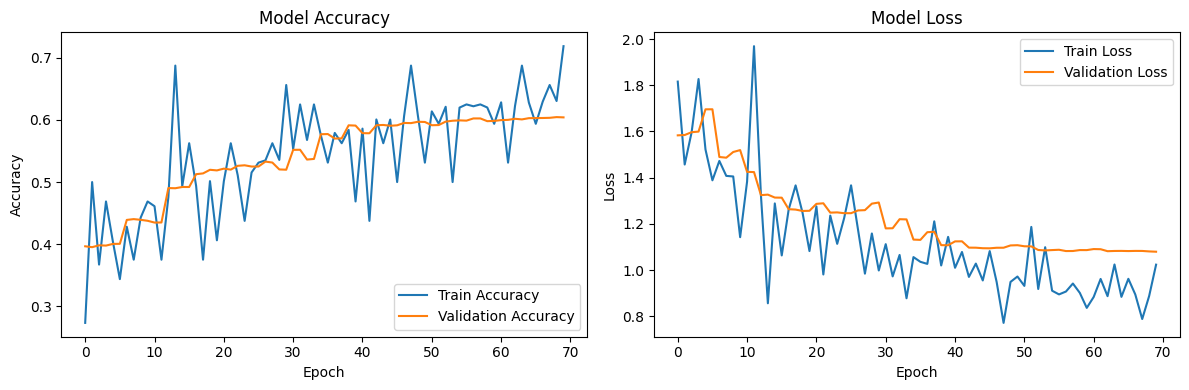

In [ ]:
# Plot training history
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_phase1.history['accuracy'] + history_phase2.history['accuracy'], label='Train Accuracy')
plt.plot(history_phase1.history['val_accuracy'] + history_phase2.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history_phase1.history['loss'] + history_phase2.history['loss'], label='Train Loss')
plt.plot(history_phase1.history['val_loss'] + history_phase2.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()